# Schizophrenia Pathway Classifier — EDA

## Objective
In this notebook I will load the `GSE21138` dataset and inspect it, by first checking data quality and class balance to ensure the data is prepared enough to do accurate analysis and determine any potential feature engineering decisions. Then, after ensuring the data is good, conduct the actual exploratory analysis — seeing if the expression data separates by diagnosis or duration in reduced dimensions. Finally, concluding with a summary of EDA findings.

## Inputs
Dataset: `GSE21138` from "Gene Expression Profiles in BA46 of Subjects with Schizophrenia and Matched Controls".

Contains 30 subjects with schizophrenia and 29 age- and sex-matched controls, Ages (18-81 years), and three duration categories (short doi=<5 yrs; intermediate doi=7-18yrs; long doi=>28 yrs). 'Cont-7' was determined to be an outlier, and was removed from the publication analysis. 

Platform: GPL570 / Affymetrix Human Genome U133 Plus 2.0 Array

## 1.1 Setup & Imports

Import necessary libraries for data manipulation and plotting: numpy, pandas, matplotlib, seaborn, GEOparse. Additionally, set theme and figure size for plots. 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import GEOparse 

sns.set_theme()
plt.rcParams['figure.figsize'] = (10, 6)

## 1.2 Data Acquisition 
To access the GEO dataset I use `GEOparse.get_GEO` to save the GEO in `../data/raw`, and then confirm data was loaded properly by checking object type and sample count. 

In [31]:
gse = GEOparse.get_GEO(geo='GSE21138', destdir="../data/raw")

18-Aug-2026 09:10:55 DEBUG utils - Directory ../data/raw already exists. Skipping.
18-Aug-2026 09:10:55 INFO GEOparse - File already exist: using local version.
18-Aug-2026 09:10:55 INFO GEOparse - Parsing ../data/raw/GSE21138_family.soft.gz: 
18-Aug-2026 09:10:55 DEBUG GEOparse - DATABASE: GeoMiame
18-Aug-2026 09:10:55 DEBUG GEOparse - SERIES: GSE21138
18-Aug-2026 09:10:55 DEBUG GEOparse - PLATFORM: GPL570
/Users/joshuasim/Desktop/summer_projects/schizophrenia-pathway-classifier/venv/lib/python3.12/site-packages/GEOparse/GEOparse.py:401: DtypeWarning: Columns (0: SPOT_ID) have mixed types. Specify dtype option on import or set low_memory=False.
  return read_csv(StringIO(data), index_col=None, sep="\t")
18-Aug-2026 09:10:56 DEBUG GEOparse - SAMPLE: GSM528831
18-Aug-2026 09:10:56 DEBUG GEOparse - SAMPLE: GSM528832
18-Aug-2026 09:10:56 DEBUG GEOparse - SAMPLE: GSM528833
18-Aug-2026 09:10:56 DEBUG GEOparse - SAMPLE: GSM528834
18-Aug-2026 09:10:56 DEBUG GEOparse - SAMPLE: GSM528835
18-Aug

In [32]:
print(type(gse))
len(gse.metadata['sample_id'])

<class 'GEOparse.GEOTypes.GSE'>


59

`.type()` returned `<class 'GEOparse.GEOTypes.GSE'>` confirming the correct object type, and `len(gse.metadata['sample_id'])` returned 59 confirming all samples were loaded. Further checks will be done to ensure samples' contents are correct. 

## 1.3 Sample Metadata Extraction & Validation

I check `GSM528831`'s, the first sample in the dataset, metadata to see where to extract information, then create a dataframe containing all samples with their diagnosis and illness duration to be used downstream (checking class balance, group comparisons, etc.). 

In [5]:
gse.gsms['GSM528831'].metadata

{'title': ['Control-1'],
 'geo_accession': ['GSM528831'],
 'status': ['Public on Mar 31 2010'],
 'submission_date': ['Mar 30 2010'],
 'last_update_date': ['Aug 12 2022'],
 'type': ['RNA'],
 'channel_count': ['1'],
 'source_name_ch1': ['prefrontal cortex'],
 'organism_ch1': ['Homo sapiens'],
 'taxid_ch1': ['9606'],
 'characteristics_ch1': ['brain region: BA46',
  'stage of illness [short doi=<5 yrs; intermediate doi=7-18yrs; long doi=>28 yrs]: short duration of illness - control',
  'Sex: M',
  'age: 38',
  'tissue ph: 6.42',
  'pmi (hrs): 46',
  'type of drug: NA',
  'drug dose (chlorpromazine equivalents): NA'],
 'molecule_ch1': ['total RNA'],
 'extract_protocol_ch1': ['Total RNA was extracted from the prefrontal cortex (Brodmann Area 46; 100 mg; left hemisphere) from all subjects as described previously (Desplats et al., 2006).  RNA quantification was determined by spectrophotometer readings, and quality by Agilent Bioanalyzer scans.  RNA integrity (RIN) numbers were not available at

Looking at `GSM528831`'s metadata, `characteristics_ch1` is the key that contains the information on diagnosis and duration of illness.

I will create a dataframe using `characteristics_ch1` to extract duration and diagnosis. 

I will do this by looping over all the samples (`gse.gsms.items()`) applying the following parsing logic to each sample to create a dictionary of sample : sampleID/duration/diagnosis: splitting `characteristics_ch1`'s second item (contains the diagnosis and duration), on `:` to get two strings - one containing the duration and diagnosis, the other containing contextual information. I will then split that list again on the second item by `-` to get a new list containing only duration information and diagnosis. Lastly, I set `diagnosis` to the split string's second item which has only the diagnosis, and set `duration` to the first item of that split, after stripping whitespace and splitting on ' ' to isolate just the duration. 

I put that dictionary into a dataframe and apply `.T` to transpose it so that each row is a sample and the columns are `['sample_id', 'duration', 'diagnosis']`. 

In [33]:
df = {}
for gsm_id, gsm_obj in gse.gsms.items():
   a = gsm_obj.metadata['characteristics_ch1'][1].split(':')
   b = a[1].split('-')
   duration = b[0].strip().split(' ')[0]
   diagnosis = b[1].strip()
   sample_id = gsm_id
   df[gsm_id] = [sample_id, duration, diagnosis]
   
gsm_df = pd.DataFrame(df).T
gsm_df.columns = ['sample_id', 'duration', 'diagnosis']
gsm_df.head()

,sample_id,duration,diagnosis
GSM528831,GSM528831,short,control
GSM528832,GSM528832,short,control
GSM528833,GSM528833,short,control
GSM528834,GSM528834,short,control
GSM528835,GSM528835,short,control


`.head()` of `gsm_df` confirms the dataframe has correactly labeld columns and rows are samples.

To further check the dataframe was constructed correctly, I will check a specific schizophrenia sample to ensure that those samples were loaded correctly, and the `.value_counts()` of `diagnosis` and `duration` to ensure the correct number of diagnoses and three duration categories are present. 

In [34]:
gsm_df.loc['GSM528885']

sample_id        GSM528885
duration              long
diagnosis    schizophrenia
Name: GSM528885, dtype: str

`GSM528885` shows `duration = long` and `diagnosis = schizophrenia` — confirming schizophrenia samples were parsed correctly.

In [35]:
print(gsm_df['diagnosis'].value_counts())
gsm_df['duration'].value_counts()

diagnosis
schizophrenia    30
control          29
Name: count, dtype: int64


duration
intermediate    28
long            16
short           15
Name: count, dtype: int64

`value_counts()` for both diagnosis and duration show the correct number of diagnoses (30 schizophrenia and 29 control — cont 7 was considered an outlier and excluded) and the three duration categories (intermediate: 28, long: 16, short: 15).

I will run a `pd.crosstab` on `diagnosis` and `duration` to check the spread of control and schizophrenia durations. 

In [36]:
pd.crosstab(gsm_df['diagnosis'], gsm_df['duration'])

duration,intermediate,long,short
diagnosis,,,
control,14,8,7
schizophrenia,14,8,8


The crosstab shows a proportional pattern (control 14/8/7 vs. schizophrenia 14/8/8) that is consistent with control being stage matched to schizophrenia subjects, even though the original study summary only explicitly states age/sex-matching. 

## 1.4 Load/Inspect Expression Matrix

To load the expression matrix, I search through `gse` directory to identify the correct method/attribute that takes samples and their actual expression values in order to use it to construct the expression matrix. After verifying which attribute/method to use, I construct and perform sanity checks on the constructed matrix to ensure it contains all the data needed for downstream analysis. 

Before looking at the methods/attributes I use `.gsms['GSM528831'].table` to look at what columns exist per sample so that I know whether a method/attribute can actually use those columns to build the expression matrix. 

In [37]:
gse.gsms['GSM528831'].table.head()

,ID_REF,VALUE
0,AFFX-BioC-5_at,8.7921
1,AFFX-BioC-3_at,9.1502
2,AFFX-BioDn-5_at,10.2670
3,AFFX-DapX-5_at,8.7025
4,AFFX-DapX-M_at,9.5005


Samples have two columns `ID_REF` and `VALUE`, so I will check which methods use those two columns to construct a matrix. 

I use `dir(gse)` to look at the different methods/attributes in `gse` to search for potential method/attribute that can be used to construct the expression matrix. 

In [4]:
dir(gse)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__metaclass__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_get_metadata_as_string',
 '_get_object_as_soft',
 '_phenotype_data',
 'database',
 'download_SRA',
 'download_supplementary_files',
 'geotype',
 'get_accession',
 'get_metadata_attribute',
 'get_type',
 'gpls',
 'gsms',
 'merge_and_average',
 'metadata',
 'name',
 'phenotype_data',
 'pivot_and_annotate',
 'pivot_samples',
 'relations',
 'show_metadata',
 'to_soft']

Looking at the different methods/attributes, I narrowed down, based on domain knowledge and using `help()` on potential candidates, to `pivot_and_annotate` and `pivot_samples` as potential candidates, since their names suggest having sample or annotated data. 

In [23]:
print(help(gse.pivot_and_annotate))
help(gse.pivot_samples)

Help on method pivot_and_annotate in module GEOparse.GEOTypes:

pivot_and_annotate(values, gpl, annotation_column, gpl_on='ID', gsm_on='ID_REF') method of GEOparse.GEOTypes.GSE instance
    Annotate GSM with provided GPL.

    Args:
        values (:obj:`str`): Column to use as values eg. "VALUES"
        gpl (:obj:`pandas.DataFrame` or :obj:`GEOparse.GPL`): A d or
            DataFrame to annotate with.
        annotation_column (:obj:`str`): Column in table for annotation.
        gpl_on (:obj:`str`, optional): Use this column in GPL to merge.
            Defaults to "ID".
        gsm_on (:obj:`str`, optional): Use this column in GSM to merge.
            Defaults to "ID_REF".

    Returns:
        pandas.DataFrame: Pivoted and annotated table of results

None
Help on method pivot_samples in module GEOparse.GEOTypes:

pivot_samples(values, index='ID_REF') method of GEOparse.GEOTypes.GSE instance
    Pivot samples by specified column.

    Construct a table in which columns (names) ar

While both methods take `ID_REF` as an index and `VALUE` as an argument, `pivot_and_annotate` also takes an annotation column, so I will use `pivot_samples` to construct the matrix since it only requires `ID_REF` and `VALUE`. 

I load the expression matrix using `.pivot_samples` with `values='VALUE'`, and then look at `.head()` to check values look real. 

In [38]:
exp_matrix = gse.pivot_samples(values='VALUE')
exp_matrix.head()

name,GSM528831,GSM528832,GSM528833,GSM528834,GSM528835,GSM528836,GSM528837,GSM528838,GSM528839,GSM528840,...,GSM528880,GSM528881,GSM528882,GSM528883,GSM528884,GSM528885,GSM528886,GSM528887,GSM528888,GSM528889
ID_REF,,,,,,,,,,,,,,,,,,,,,
1007_s_at,10.0887,9.1448,9.5847,9.2438,9.0333,9.3003,9.2000,9.3305,9.0366,9.6668,...,9.4743,10.1502,9.2517,9.0640,9.5347,9.7102,9.6754,10.0982,9.8905,10.4207
1053_at,7.0144,7.0536,6.9642,7.2024,6.6731,6.9244,6.9524,6.9647,6.6808,7.0324,...,6.1323,6.6461,6.7076,6.8556,7.1541,7.2579,6.9427,6.7352,6.8509,7.1291
117_at,4.8340,5.1611,4.9111,5.2503,4.8153,4.5898,4.2863,4.8058,4.8646,5.0324,...,8.1406,5.4431,4.6838,5.0441,5.3910,4.1443,4.8502,4.8425,4.0438,5.2339
121_at,7.9776,8.5253,8.1324,7.6403,7.4291,8.1697,7.1497,7.9566,8.2069,7.9247,...,7.6873,7.9584,7.5622,7.9827,7.7387,7.5936,7.8277,7.6981,7.7678,7.1596
1255_g_at,5.3040,5.8394,5.3994,5.5726,5.3081,5.4553,5.1663,5.7873,6.0013,5.1592,...,5.4498,4.9400,4.6725,5.5831,5.0636,5.5238,5.2938,5.1384,4.5343,4.7568


Looking at the first five rows of the expression matrix, the values range from roughly 4-10. Given that raw values would typically be in the hundreds/thousands, I suspect the values have already been log2-transformed (standard practice for microarray data), so I will further confirm this by using `.describe()`. 

In [29]:
exp_matrix.describe()

name,GSM528831,GSM528832,GSM528833,GSM528834,GSM528835,GSM528836,GSM528837,GSM528838,GSM528839,GSM528840,...,GSM528880,GSM528881,GSM528882,GSM528883,GSM528884,GSM528885,GSM528886,GSM528887,GSM528888,GSM528889
count,30061.000000,30061.000000,30061.000000,30061.000000,30061.000000,30061.000000,30061.000000,30061.000000,30061.000000,30061.000000,...,30061.000000,30061.000000,30061.000000,30061.000000,30061.000000,30061.000000,30061.000000,30061.000000,30061.000000,30061.000000
mean,6.096415,6.096083,6.084213,5.989972,5.996463,6.043386,6.009915,6.051067,6.087311,6.055251,...,6.157749,6.176198,5.882081,6.074273,6.036868,6.027844,6.066820,6.197870,6.073197,6.084032
std,1.609117,1.565847,1.579749,1.590782,1.605292,1.571401,1.601515,1.556544,1.549775,1.593954,...,1.634704,1.639886,1.664364,1.549392,1.593269,1.608989,1.606358,1.608165,1.589823,1.677716
min,2.077700,2.115400,2.156900,2.165800,2.165800,1.973500,2.114500,2.208000,2.158900,2.114500,...,2.056600,2.032400,1.894600,2.144300,2.109300,2.165400,2.222600,2.217500,2.165400,2.160900
25%,4.914300,4.943200,4.916100,4.821800,4.822300,4.896700,4.830800,4.899200,4.944700,4.862200,...,4.965500,4.955900,4.689600,4.929800,4.856500,4.837500,4.883900,5.010400,4.904800,4.835700
50%,5.807000,5.836600,5.798900,5.691300,5.700600,5.771500,5.710600,5.772500,5.816800,5.761200,...,5.906300,5.892100,5.614500,5.787200,5.744600,5.730400,5.753800,5.909600,5.774200,5.776500
75%,7.061100,7.033600,7.010800,6.941200,6.961600,6.943700,6.962600,6.959200,6.978200,7.019700,...,7.161800,7.164000,6.846500,6.982300,6.996400,6.988900,7.006500,7.152500,7.013800,7.140400
max,12.752700,12.778100,12.805800,12.818400,12.834500,12.703500,12.769400,12.757200,12.783900,12.770600,...,13.354800,12.789800,12.651200,12.754900,12.825200,33.794900,34.940900,32.309000,12.745600,34.840700


This shows that the majority of samples range from roughly 2-12, with a `mean` of ~6, confirming the values are already log2 transformed so I will not need to transform values in feature engineering. Samples `GSM528885`, `GSM528886`, `GSM528887`, and `GSM528889` have `max` above 30, but `mean` ~7, meaning they likely have a singular outlier probe (~30) that is pulling the `mean`. I will confirm this data quality issue in the next section. 

Further checking the matrix was loaded correctly, I perform sanity checks on the expression matrix using `.shape` to ensure rows/columns are correct, and check if `exp_matrix` samples match the `gsm_df` samples. 

In [26]:
print(exp_matrix.shape)
exp_matrix.columns == gsm_df['sample_id']

(30061, 59)


GSM528831    True
GSM528832    True
GSM528833    True
GSM528834    True
GSM528835    True
GSM528836    True
GSM528837    True
GSM528838    True
GSM528839    True
GSM528840    True
GSM528841    True
GSM528842    True
GSM528843    True
GSM528844    True
GSM528845    True
GSM528846    True
GSM528847    True
GSM528848    True
GSM528849    True
GSM528850    True
GSM528851    True
GSM528852    True
GSM528853    True
GSM528854    True
GSM528855    True
GSM528856    True
GSM528857    True
GSM528858    True
GSM528859    True
GSM528860    True
GSM528861    True
GSM528862    True
GSM528863    True
GSM528864    True
GSM528865    True
GSM528866    True
GSM528867    True
GSM528868    True
GSM528869    True
GSM528870    True
GSM528871    True
GSM528872    True
GSM528873    True
GSM528874    True
GSM528875    True
GSM528876    True
GSM528877    True
GSM528878    True
GSM528879    True
GSM528880    True
GSM528881    True
GSM528882    True
GSM528883    True
GSM528884    True
GSM528885    True
GSM528886 

`.shape` confirms the correct number of samples were included (59), but the row count 30061 suggests something got filtered/collapsed upstream somewhere since GPL570 platform normally has 54,675 probesets. This difference is not a loading error introduced during matrix construction since `len(gse.gsms['GSM528831'].table)` gives the same 30061 count, meaning the reduction happened before it was deposited in GEO — likely a filtering step applied by the submitters. I checked the papers methods section for any mention of this but could not find anything on microarray preprocessing. I leave this as a documented open question rather than resolving since it doesn't change my modeling approach. 

The boolean I used to compare the samples in `exp_matrix` and `gsm_df` returned `True` for all samples which confirms all samples were included on the expression matrix.

## 1.5 Data Quality Check

In this section I perform data quality checks looking for outliers, which would cause poor clustering — PCA/k-means are variance based methods, an outlier would skew variance pulling components/centroids away from the schizophrenia vs. control signal I'm testing for resulting in inaccurate analysis and modeling, and missing values, which would prevent PCA/k-means from running. 

In order to visually identify any outliers across all samples, I will use a boxplot. To do this I first apply `.reset_index()` to `exp_matrix` and then `.melt(id_vars="ID_REF", var_name="sample_id", value_name="expression_value")` on the reset matrix so that it can be used in the box plot with each row being a single (probe, sample) sample and the columns being the `ID_REF`, `expression_value`, and `sample_id`. This will allow me to see which samples (beyond the 4 identified in the previous section) contain outliers.

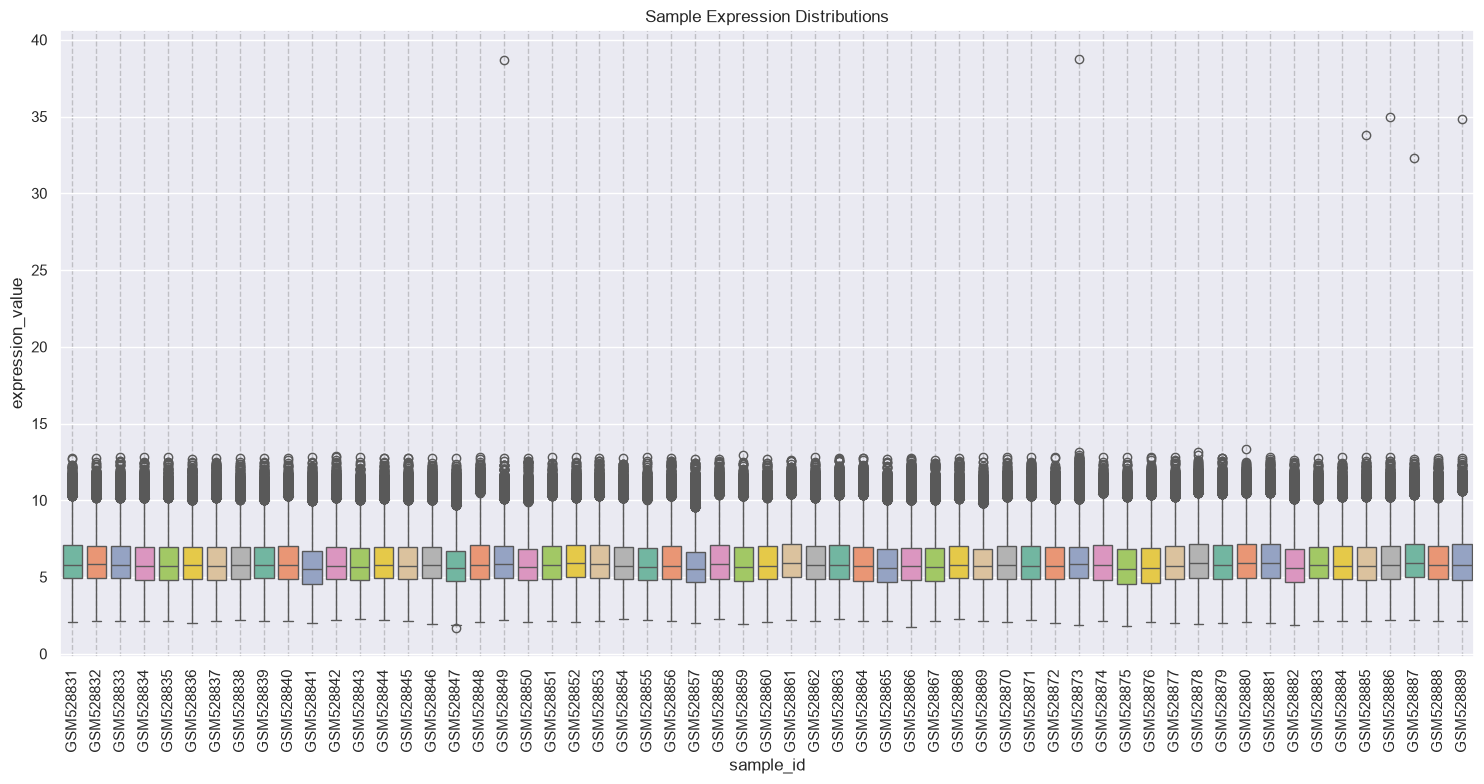

In [83]:
exp_matrix_reset = exp_matrix.reset_index()
exp_matrix_long = exp_matrix_reset.melt(id_vars="ID_REF", var_name="sample_id", value_name="expression_value")

plt.figure(figsize=(15, 8))

ax = sns.boxplot(data=exp_matrix_long, x="sample_id", y="expression_value", hue="sample_id", palette="Set2", legend=False)
ax.set_xticks(range(len(exp_matrix_long["sample_id"].unique())))
ax.set_xticklabels(exp_matrix_long["sample_id"].unique(), rotation=90, ha="center")
ax.set_title("Sample Expression Distributions")
ax.grid(axis='x', which='major', linestyle='--', alpha=0.4, color="gray")


plt.tight_layout()
plt.savefig("../images/sample_expression_distributions.png")
plt.show()


In [89]:
for s in ['GSM528849','GSM528873', 'GSM528885', 'GSM528886', 'GSM528887', 'GSM528889']:
    print(s)
    print(exp_matrix[s].sort_values(ascending=False).head())
    print('\n')

GSM528849
ID_REF
224264_x_at     38.6962
202508_s_at     12.7527
229606_at       12.5591
1558678_s_at    12.3128
229921_at       12.3043
Name: GSM528849, dtype: float64


GSM528873
ID_REF
224264_x_at     38.7521
1558678_s_at    13.1530
209116_x_at     12.9652
211745_x_at     12.8423
225491_at       12.8335
Name: GSM528873, dtype: float64


GSM528885
ID_REF
224264_x_at    33.7949
202508_s_at    12.8271
211696_x_at    12.5588
225491_at      12.4481
201360_at      12.4467
Name: GSM528885, dtype: float64


GSM528886
ID_REF
224264_x_at    34.9409
202508_s_at    12.7999
225491_at      12.5725
227556_at      12.5518
201360_at      12.4382
Name: GSM528886, dtype: float64


GSM528887
ID_REF
224264_x_at     32.3090
202508_s_at     12.7041
225491_at       12.5548
1558678_s_at    12.4311
201360_at       12.4241
Name: GSM528887, dtype: float64


GSM528889
ID_REF
224264_x_at    34.8407
202508_s_at    12.7400
203540_at      12.6490
212185_x_at    12.4677
210198_s_at    12.3781
Name: GSM528889, dtype:

The box plot shows six samples with extreme outliers: `GSM528849` (~38.70), `GSM528873`(~38.75), and the four previously identified samples `GSM528885`(~33.79), `GSM528886`(~34.94), `GSM528887`(~32.31), and `GSM528889`(~34.84). I check the samples in `exp_matrix` with values sorted in descending order, giving me the exact values and see which `ID_REF` the outliers are occurring at. For all six outlier samples, the `224264_x_at` probe is producing the outliers, while all other samples' distributions are normal. This suggests the problem is due to a probe-level artifact rather than an independent sample-level issue. 

Additionally, there is a dot for sample `GSM528847`, but after checking separately I determined `GSM528847`'s minimum value (~1.67) was not meaningfully different from the other samples' minimums to be considered an outlier. 

To check for any missing values I use `isna().sum()` to get the number of `NaN` in every sample.

In [93]:
exp_matrix.isna().sum()

name
GSM528831    0
GSM528832    0
GSM528833    0
GSM528834    0
GSM528835    0
GSM528836    0
GSM528837    0
GSM528838    0
GSM528839    0
GSM528840    0
GSM528841    0
GSM528842    0
GSM528843    0
GSM528844    0
GSM528845    0
GSM528846    0
GSM528847    0
GSM528848    0
GSM528849    0
GSM528850    0
GSM528851    0
GSM528852    0
GSM528853    0
GSM528854    0
GSM528855    0
GSM528856    0
GSM528857    0
GSM528858    0
GSM528859    0
GSM528860    0
GSM528861    0
GSM528862    0
GSM528863    0
GSM528864    0
GSM528865    0
GSM528866    0
GSM528867    0
GSM528868    0
GSM528869    0
GSM528870    0
GSM528871    0
GSM528872    0
GSM528873    0
GSM528874    0
GSM528875    0
GSM528876    0
GSM528877    0
GSM528878    0
GSM528879    0
GSM528880    0
GSM528881    0
GSM528882    0
GSM528883    0
GSM528884    0
GSM528885    0
GSM528886    0
GSM528887    0
GSM528888    0
GSM528889    0
dtype: int64

All samples have sum of 0, which means there are no missing values in the samples. 

## 1.6 Merge Expression Data With Labels

In this section I build a merged dataframe, merging `gsm_df` and `exp_matrix` transposed, since current `exp_matrix` has each sample as a column and not row — scikit-learn expects samples as rows and features as columns, so any scikit-learn uses would fail without the transpose. Then I confirm the class balance held through the merge by using `.value_counts()` by `diagnosis` to ensure that the merged dataframe is correct and ready to be used in dimensionality reduction.

In [99]:
exp_matrix_T = exp_matrix.T.reset_index()
merged_df = pd.merge(gsm_df, exp_matrix_T, left_on='sample_id', right_on='name')
print(len(merged_df))
merged_df.value_counts('diagnosis')

59


diagnosis
schizophrenia    30
control          29
Name: count, dtype: int64

The `len` of `merged_df` is 59 matching the number of samples, and the diagnosis split of schizophrenia 30 and control 29 matches the correct split. This confirms the two dataframes were merged correctly, maintaining its structure (59 rows) and labels (30/29 schizophrenia/control split).

## 1.7 Dimensionality Reduction — PCA

## 1.8 Clustering

## 1.9 EDA Summary 